In [1]:
import importlib
import numpy as np
import polars as pl
import scipy.sparse as sp
import torch
import torch.nn as nn
from tqdm import tqdm

from datasets import DATA_FOLDER, Dataloader, prepare_interaction_data
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

DATASET = "ML-25M"
#old
#checkpoint = "TopKSAE-8192-b457e403.ckpt" #multvae
#checkpoint = "TopKSAE-8192-7420ec46.ckpt" #cosine
#checkpoint = "TopKSAE-8192-c347146b.ckpt" #l2

#checkpoint = "TopKSAE-8192-f634db83.ckpt" #multvae
#checkpoint = "TopKSAE-8192-3c29e9ee.ckpt" #cosine
checkpoint = "TopKSAE-8192-d6337b64.ckpt" #l2

SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/{checkpoint}"


sae_cfg = load_config_from_checkpoint(SAE_CHECKPOINT_PATH)
cf_model_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{sae_cfg['pretrained_model_checkpoint']}"
cf_model_cfg = load_config_from_checkpoint(cf_model_checkpoint_path)

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(cf_model_cfg)
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}

items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/movies.csv").rename({"movieId": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)


cf_model_class = getattr(importlib.import_module(cf_model_cfg["model_module"]), cf_model_cfg["model_class"])
if cf_model_cfg["model_class"] == "ELSA":
    cf_model = cf_model_class(train_csr.shape[1], cf_model_cfg["embedding_dim"]).to(device)
elif cf_model_cfg["model_class"] == "MultVAE":
    cf_model = cf_model_class(
        train_csr.shape[1],
        [int(x) for x in cf_model_cfg["hidden_dims"].split(",") if x.strip()],
        cf_model_cfg["embedding_dim"],
        cf_model_cfg["annealing_beta"],
        cf_model_cfg["annealing_steps"],
    ).to(device)

_, _ = load_checkpoint(cf_model, None, get_checkpoint_filepath(cf_model_cfg), device, None)

sae_model_class = getattr(importlib.import_module(sae_cfg["model_module"]), sae_cfg["model_class"])
sae_extra_params = {k: sae_cfg[k] for k in sae_cfg.keys() if k in ["l1_coef", "k"]}
sae = sae_model_class(cf_model_cfg["embedding_dim"], sae_cfg["embedding_dim"], sae_cfg["reconstruction_loss"], l1_coef=sae_cfg["l1_coef"], k=sae_cfg["k"]).to(
    device
)
_, _ = load_checkpoint(sae, None, get_checkpoint_filepath(sae_cfg), device, None)

Removing users with < 5 interactions...
Dataset info: users=160776, items=40857, interactions=12448242
Train split info: users=128621, items=40857, interactions=9959297
Val split info: users=16078, items=40857, interactions=1264850
Test split info: users=16077, items=40857, interactions=1224095
Loaded checkpoint from checkpoints/ML-25M/ELSA-1024-10977915.ckpt (after 13 epochs)
Loaded checkpoint from checkpoints/ML-25M/TopKSAE-8192-d6337b64.ckpt (after 761 epochs)


In [2]:
sparse_embeddings = []
onehot_items_dataloader = Dataloader(sp.eye(len(items), dtype=np.float32, format="csr"), batch_size=1024, device=device)
with torch.no_grad():
    for onehot_batch in tqdm(onehot_items_dataloader):
        cf_model_embedding = cf_model.encode(onehot_batch)  # Tensor, shape = (batch.shape[0] x elsa_cfg["embedding_dim"])
        if cf_model_cfg["model_class"] != "ELSA":
            cf_model_embedding = cf_model_embedding[0]
        
        sae_embedding, _, input_mean, input_std = sae.encode(cf_model_embedding)
        sparse_embeddings.append(sp.csr_matrix(sae_embedding.cpu().numpy()))
sparse_embeddings = sp.vstack(sparse_embeddings)

neuron_is_alive = np.asarray(sparse_embeddings.sum(axis=0)).flatten() != 0
living_neurons = np.where(neuron_is_alive)[0]
dead_neuron_count = sparse_embeddings.shape[1] - neuron_is_alive.sum()
print(f"{dead_neuron_count} dead neurons out of {sparse_embeddings.shape[1]} ({dead_neuron_count / sparse_embeddings.shape[1]:.2%})")
print(f"{neuron_is_alive.sum()} alive ones")

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:21<00:00,  1.88it/s]

4267 dead neurons out of 8192 (52.09%)
3925 alive ones


In [3]:
tag_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/tags.csv")
    .rename({"userId": "user_id", "movieId": "item_id"})
    .cast({"user_id": pl.String, "item_id": pl.String})
    .cast({"user_id": pl.Categorical, "item_id": pl.Categorical})
    .with_columns(pl.col("tag").str.to_lowercase().str.strip_chars().alias("tag"))  # convert to lowercase and strip whitespace
    .filter(pl.col("tag").count().over("tag") >= 100)  # keep only tags assigned at least 100 times
    .filter(pl.col("item_id").is_in(items))  # keep only items with interactions
    .with_columns(pl.col("item_id").replace_strict(items_to_idxs).alias("item_idx"))
    .cast({"tag": pl.Categorical})
    .collect()
)

tag_df

sys:1: CategoricalRemappingWarning: Local categoricals have different encodings, expensive re-encoding is done to perform this merge operation. Consider using a StringCache or an Enum type if the categories are known in advance


user_id,item_id,tag,timestamp,item_idx
cat,cat,cat,i64,i64
"""3""","""260""","""classic""",1439472355,43
"""3""","""260""","""sci-fi""",1439472256,43
"""4""","""1732""","""dark comedy""",1573943598,181
"""4""","""1732""","""great dialogue""",1573943604,181
"""4""","""7569""","""so bad it's good""",1573943455,5010
…,…,…,…,…
"""162462""","""260""","""space""",1427470029,43
"""162492""","""260""","""classic sci-fi""",1436468895,43
"""162492""","""260""","""epic""",1436468882,43


In [4]:
tags = tag_df["tag"].unique(maintain_order=True).to_numpy()
tag_item_counts = sp.csr_matrix(
    (
        np.ones(len(tag_df), dtype=np.float32),
        (
            tag_df["tag"].to_physical().to_numpy(),
            tag_df["item_idx"].to_numpy(),
        ),
    ),
    shape=(tag_df["tag"].n_unique(), len(items)),
)

tag_item_counts

<1633x40857 sparse matrix of type '<class 'numpy.float32'>'
	with 209685 stored elements in Compressed Sparse Row format>

In [5]:
pl.Series(tag_item_counts.data).describe()

statistic,value
str,f64
"""count""",209685.0
"""null_count""",0.0
"""mean""",3.42385
"""std""",8.698483
"""min""",1.0
"""25%""",1.0
"""50%""",1.0
"""75%""",2.0
"""max""",658.0


In [6]:
def compute_tfidf(X):
    """
    Compute TF-IDF for a term-document value matrix.
    Parameters:
    X: np.ndarray (num_terms, num_documents)
    Returns:
    tfidf_matrix: np.ndarray (num_terms, num_documents) - TF-IDF values
    """
    # Compute Term Frequency (TF) - Normalize by column sum
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0  # Handle division by zero
    # Compute Document Frequency (DF) - Count nonzero occurrences of each term
    df = np.count_nonzero(X, axis=1)
    # Compute Inverse Document Frequency (IDF) - Log-scaled
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1  # Smoothing
    # Compute TF-IDF
    tfidf_matrix = tf * idf[:, np.newaxis]
    return tfidf_matrix


pti = tag_item_counts.copy()
pti.data /= pti.data.sum()
tag_neuron_activity = pti @ sparse_embeddings

#top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=0)]  # term = tag, document = neuron
top_tag_per_neuron = tags[compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=1)]  # term = neuron, document = tag
top_tag_per_neuron[~neuron_is_alive] = None

#top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray().T).argmax(axis=0)  # term = neuron, document = tag
top_neuron_per_tag = compute_tfidf(tag_neuron_activity.toarray()).argmax(axis=1)  # term = tag, document = neuron

print(pl.Series("top_neuron", top_neuron_per_tag).value_counts(sort=True))
print(pl.Series("top_tag", top_tag_per_neuron[neuron_is_alive]).value_counts(sort=True))

C:\Users\lpesk\AppData\Local\Temp\ipykernel_10848\1404268557.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


shape: (833, 2)
┌────────────┬───────┐
│ top_neuron ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 2041       ┆ 7     │
│ 5468       ┆ 7     │
│ 464        ┆ 7     │
│ 6535       ┆ 7     │
│ 7135       ┆ 7     │
│ …          ┆ …     │
│ 7920       ┆ 1     │
│ 5093       ┆ 1     │
│ 1356       ┆ 1     │
│ 2786       ┆ 1     │
│ 157        ┆ 1     │
└────────────┴───────┘
shape: (985, 2)
┌──────────────────┬───────┐
│ top_tag          ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ audrey hepburn   ┆ 19    │
│ aardman          ┆ 18    │
│ woody allen      ┆ 18    │
│ sergio leone     ┆ 17    │
│ monty python     ┆ 16    │
│ …                ┆ …     │
│ prostitute       ┆ 1     │
│ darren aronofsky ┆ 1     │
│ wheelchair       ┆ 1     │
│ kick-butt women  ┆ 1     │
│ government       ┆ 1     │
└──────────────────┴───────┘


In [7]:
pl.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort(by="top neuron").tail(10)

tag,top neuron
str,i64
"""castle""",8166
"""crazy""",8167
"""dystopia""",8182
"""future""",8182
"""cars""",8182
"""government""",8182
"""x-men""",8184
"""bad script""",8184
"""mutants""",8184


In [31]:
import pandas as pd
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("han")]


,tag,top neuron
262,tom hanks,172
877,zooey deschanel,1108
872,jackie chan,1237
90,orphans,1421
1306,hannibal lecter,2491
215,afghanistan,2599
943,ethan hawke,2932
532,scarlett johansson,3014
1099,chan-wook park,4150
1508,orphan,5223


In [33]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"]==2491]

,tag,top neuron
1060,ralph fiennes,2491
828,anthony hopkins,2491
774,edward norton,2491
940,fbi,2491
1306,hannibal lecter,2491


In [32]:
top_tag_per_neuron[2491]

'hannibal lecter'

In [46]:
import pandas as pd
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.iloc[400:450]


,tag,top neuron
769,scotland,1782
208,sad,1782
1055,australian,1783
995,flashback,1783
1516,car crash,1783
1481,baby,1783
505,stylish,1792
153,cynical,1792
165,jude law,1802
156,psychology,1802


In [47]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df.tag.str.contains("hans")]

,tag,top neuron
90,orphans,1421
532,scarlett johansson,3014
34,hans zimmer,7599


In [48]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"]==7599]

,tag,top neuron
1038,rome,7599
1222,ridley scott,7599
1559,heroism,7599
34,hans zimmer,7599


In [50]:
df = pd.DataFrame({"tag": tags, "top neuron": top_neuron_per_tag}).sort_values("top neuron")
df.loc[df["top neuron"]==2491]

,tag,top neuron
1060,ralph fiennes,2491
828,anthony hopkins,2491
774,edward norton,2491
940,fbi,2491
1306,hannibal lecter,2491


In [56]:
tag_df.filter(pl.col("tag") == "hannibal lecter")["item_id"].unique()

item_id
cat
"""593"""
"""4148"""
"""4210"""
"""5630"""
"""50804"""


In [12]:
list(tag_df.filter(pl.col("item_id") == "260")["tag"].unique())

['classic',
 'sci-fi',
 'horror',
 'adventure',
 'anime',
 'fantasy',
 'music',
 'aliens',
 'franchise',
 'science fiction',
 'space',
 'space travel',
 'boring',
 'love story',
 'philosophy',
 'thought-provoking',
 'drama',
 'war',
 'western',
 'atmospheric',
 'incest',
 'friendship',
 'usa',
 'love',
 'oscar winner',
 'robots',
 'star wars',
 'funny',
 'action',
 'george lucas',
 'romance',
 'family',
 'mystery',
 'interesting',
 'thriller',
 'dialogue',
 'touching',
 'gay',
 'soundtrack',
 'politics',
 'humorous',
 'nostalgic',
 'alternate reality',
 'children',
 'story',
 'original plot',
 'original',
 'espionage',
 'future',
 'good acting',
 'slow',
 'acting',
 'oscar nominee: best picture',
 'space adventure',
 'witty',
 'smart',
 'cult film',
 'dark',
 'inspiring',
 'magic',
 'innovative',
 'special effects',
 'cult classic',
 'great soundtrack',
 'stylized',
 'comedy',
 'awesome',
 'classic sci-fi',
 'good vs evil',
 'futuristic',
 'coming of age',
 'rebellion',
 'quotable',
 '

In [13]:
top_tag_per_neuron[6040]

'space action'

In [14]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray().T) # term = neuron, document = tag
normalized_tag_neuron_activity.shape

(8192, 1633)

In [15]:
mean_neuron_activity = normalized_tag_neuron_activity.sum(axis=0)
mean_neuron_activity.shape

(1633,)

In [16]:
epsilon=1e-9
import pandas as pd
from scipy.stats import entropy
neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_neurons = []

for n in range(normalized_tag_neuron_activity.shape[0]):
    neron_tag_activation = normalized_tag_neuron_activity[n,:]
    if neron_tag_activation.sum() >0 : #living neuron        
        n_entropy = entropy(neron_tag_activation)
        
        neron_tag_activation = neron_tag_activation.copy() + epsilon        
        n_kl_div = entropy(mean_neuron_activity,neron_tag_activation)
        #n_kl_div = entropy(neron_tag_activation,mean_neuron_activity)
        
        valid_neurons.append(n)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)

        
res = pd.DataFrame({
    "id":valid_neurons, 
    "entropy":neuron_entropy, 
    "KL_div":neuron_kl_div
    })
res

,id,entropy,KL_div
0,0,4.654860,10.606114
1,1,5.583304,8.705949
2,2,0.950126,7.309413
3,3,4.772311,11.272472
4,5,5.173847,8.894015
...,...,...,...
3911,8179,5.450979,7.286768
3912,8182,0.683266,6.757640
3913,8184,2.951686,10.993359
3914,8188,3.396090,9.572593


In [17]:
res["norm_entropy_diff"] = (entropy(mean_neuron_activity) - res.entropy) / entropy(mean_neuron_activity)

In [18]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_neuron_tag_{chckpt_name}.csv")

In [19]:
entropy(mean_neuron_activity)

7.397464169121402

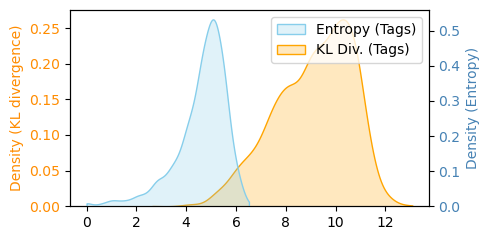

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res['entropy'].min()
max_entropy = res['entropy'].max()

min_kldiv = res['KL_div'].min()
max_kldiv = res['KL_div'].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis='y', labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis='y', labelcolor="#4682B4")


# Add a title and legend
#plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc='upper right')
fig.tight_layout()

#ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_neuron_tag_tfidf.pdf")

In [21]:
normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.toarray()).T # term = tag, document = neuron
normalized_tag_neuron_activity.shape

C:\Users\lpesk\AppData\Local\Temp\ipykernel_10848\1404268557.py:10: RuntimeWarning: invalid value encountered in divide
  tf = X / np.sum(X, axis=0, keepdims=True)


(8192, 1633)

In [22]:
mean_tag_activity = normalized_tag_neuron_activity.sum(axis=1)
mean_tag_activity.shape

(8192,)

In [23]:
import pandas as pd
from scipy.stats import entropy
neuron_entropy = []
neuron_kl_div = []
neuron_top_tags = []
neuron_top_movies = []
valid_tags = []

for t in range(normalized_tag_neuron_activity.shape[1]):
    neron_tag_activation = normalized_tag_neuron_activity[:,t]
    if neron_tag_activation.sum() >0 : #living neuron        
        n_entropy = entropy(neron_tag_activation)
        
        neron_tag_activation = neron_tag_activation.copy() + epsilon        
        n_kl_div = entropy(mean_tag_activity,neron_tag_activation)
        #n_kl_div = entropy(neron_tag_activation,mean_tag_activity)
        
        valid_tags.append(t)
        neuron_entropy.append(n_entropy)
        neuron_kl_div.append(n_kl_div)

        
res = pd.DataFrame({
    "id":valid_tags, 
    "tag":tags[valid_tags],
    "entropy":neuron_entropy, 
    "KL_div":neuron_kl_div
    })
res

,id,tag,entropy,KL_div
0,0,classic,6.982862,5.709633
1,1,sci-fi,7.045282,6.284342
2,2,dark comedy,6.712614,6.725684
3,3,great dialogue,5.256324,12.310893
4,4,so bad it's good,5.591165,9.991120
...,...,...,...,...
1628,1628,02/11,6.283592,8.346408
1629,1629,03/11,6.338118,8.222719
1630,1630,05/11,6.424846,8.146017
1631,1631,06/11,6.599973,7.901838


In [24]:
res["norm_entropy_diff"] = (entropy(mean_tag_activity) - res.entropy) / entropy(mean_tag_activity)

In [25]:
chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
res.to_csv(f"results/res_tag_neuron_{chckpt_name}.csv")

In [26]:
entropy(mean_tag_activity)

8.27151530351057

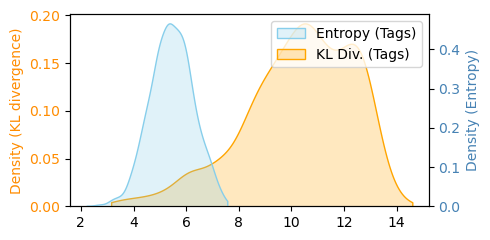

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

min_entropy = res['entropy'].min()
max_entropy = res['entropy'].max()

min_kldiv = res['KL_div'].min()
max_kldiv = res['KL_div'].max()

# Initialize the plot
fig, ax2 = plt.subplots(figsize=(5, 2.5))

sns.kdeplot(res["KL_div"], ax=ax2, label="KL Div. (Tags)", fill=True, color="orange", linestyle="-", clip=(min_kldiv, max_kldiv))

ax2.set_ylabel("Density (KL divergence)", color="#FF8C00")
ax2.tick_params(axis='y', labelcolor="#FF8C00")

# Create a second y-axis for KL_div
ax1 = ax2.twinx()


# Plot the KDE for entropy on the first y-axis
sns.kdeplot(res["entropy"], ax=ax1, label="Entropy (Tags)", fill=True, color="skyblue", linestyle="-", clip=(min_entropy, max_entropy))

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Entropy)", color="#4682B4")
ax1.tick_params(axis='y', labelcolor="#4682B4")


# Add a title and legend
#plt.title("KDE of Entropy and KL Divergence with Dual Axes")
handles, labels = ax1.get_legend_handles_labels()  # Get handles and labels from ax1
handles2, labels2 = ax2.get_legend_handles_labels()  # Get handles and labels from ax2

# Combine the handles and labels from both axes
handles.extend(handles2)
labels.extend(labels2)

# Show the legend
plt.legend(handles=handles, labels=labels, loc='upper right')
fig.tight_layout()

#ax1.set_xlim(-0.5, 24)
plt.savefig("rq2_tag_neuron_tfidf.pdf")

In [28]:
res.sort_values("entropy")

,id,tag,entropy,KL_div,norm_entropy_diff
1407,1407,horse,2.214370,10.888677,0.732290
975,975,relativity,2.664937,12.444980,0.677818
459,459,space action,2.706732,12.376198,0.672765
1299,1299,shark,2.710060,11.989310,0.672362
35,35,philosophical issues,3.044729,12.226146,0.631902
...,...,...,...,...,...
91,91,funny,7.389216,3.601093,0.106667
1605,1605,dvd-video,7.423061,3.384202,0.102575
54,54,drama,7.455001,3.353933,0.098714
1598,1598,bd-video,7.515565,3.533930,0.091392


In [29]:
res.sort_values("KL_div")

,id,tag,entropy,KL_div,norm_entropy_diff
41,41,boring,7.326372,3.148817,0.114265
61,61,based on a book,7.562723,3.334225,0.085691
54,54,drama,7.455001,3.353933,0.098714
1605,1605,dvd-video,7.423061,3.384202,0.102575
173,173,murder,7.237120,3.423816,0.125055
...,...,...,...,...,...
259,259,coen brothers,4.814886,13.987035,0.417896
502,502,monty python,3.515508,14.038856,0.574986
785,785,stanley kubrick,4.501919,14.199126,0.455732
925,925,wes anderson,4.085897,14.247551,0.506028
